# Fourier Transform Image Filtering
**Topics Covered:** Fourier Transformation, Low-pass, High-pass, Band-pass Filtering (Ideal & Gaussian), Inverse Transformation, Downsampling & Aliasing

## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from skimage import data, color, transform
from skimage.util import img_as_float

plt.rcParams['figure.dpi'] = 100
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Test Image (Cameraman)
We use the standard **Cameraman** grayscale test image (256×256).

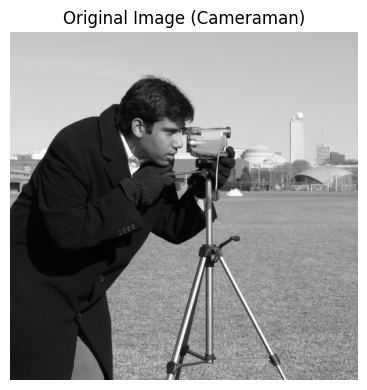

Image shape: (512, 512), dtype: float64


In [2]:
# Load grayscale test image
image = img_as_float(data.camera())   # 256x256 grayscale

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title('Original Image (Cameraman)')
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Image shape: {image.shape}, dtype: {image.dtype}')

## 3. Helper Functions

In [3]:
# ─────────────────────────────────────────────
# 3.1  Fourier Transform & centered magnitude spectrum
# ─────────────────────────────────────────────
def compute_fft(img):
    """Compute 2D FFT and return (F_shift, magnitude_spectrum_log)."""
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)          # center DC component
    magnitude = np.abs(F_shift)
    log_mag = np.log1p(magnitude)         # log scale for display
    return F_shift, log_mag


# ─────────────────────────────────────────────
# 3.2  Distance map from center (used by all filters)
# ─────────────────────────────────────────────
def distance_map(shape):
    """Return a 2-D array of Euclidean distances from the image center."""
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    u = np.arange(rows) - crow
    v = np.arange(cols) - ccol
    V, U = np.meshgrid(v, u)
    return np.sqrt(U**2 + V**2)


# ─────────────────────────────────────────────
# 3.3  Ideal filters
# ─────────────────────────────────────────────
def ideal_lowpass(shape, cutoff):
    D = distance_map(shape)
    H = (D <= cutoff).astype(float)
    return H

def ideal_highpass(shape, cutoff):
    return 1.0 - ideal_lowpass(shape, cutoff)

def ideal_bandpass(shape, low_cut, high_cut):
    D = distance_map(shape)
    H = ((D >= low_cut) & (D <= high_cut)).astype(float)
    return H


# ─────────────────────────────────────────────
# 3.4  Gaussian filters
# ─────────────────────────────────────────────
def gaussian_lowpass(shape, sigma):
    D = distance_map(shape)
    H = np.exp(-(D**2) / (2 * sigma**2))
    return H

def gaussian_highpass(shape, sigma):
    return 1.0 - gaussian_lowpass(shape, sigma)

def gaussian_bandpass(shape, sigma_low, sigma_high):
    """Band = difference between two Gaussian LP filters."""
    H = gaussian_lowpass(shape, sigma_high) - gaussian_lowpass(shape, sigma_low)
    return np.clip(H, 0, None)


# ─────────────────────────────────────────────
# 3.5  Apply filter & inverse FFT
# ─────────────────────────────────────────────
def apply_filter(F_shift, H):
    """Multiply spectrum by filter H and return the reconstructed spatial image."""
    filtered_shift = F_shift * H
    filtered_log   = np.log1p(np.abs(filtered_shift))   # for display
    # Inverse FFT
    F_ishift = np.fft.ifftshift(filtered_shift)
    img_back = np.fft.ifft2(F_ishift)
    img_back = np.abs(img_back)
    img_back = np.clip(img_back, 0, 1)
    return img_back, filtered_log


# ─────────────────────────────────────────────
# 3.6  Visualise one filter result (3-panel)
# ─────────────────────────────────────────────
def show_result(original, orig_log, filtered_log, result, title):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(original,     cmap='gray');       axes[0].set_title('Original Image')
    axes[1].imshow(filtered_log, cmap='gray');       axes[1].set_title(f'Filtered Spectrum\n({title})')
    axes[2].imshow(result,       cmap='gray');       axes[2].set_title(f'Reconstructed Image\n({title})')
    for ax in axes:
        ax.axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Helper functions defined.')

Helper functions defined.


## 4. Fourier Transform — Centered Magnitude Spectrum

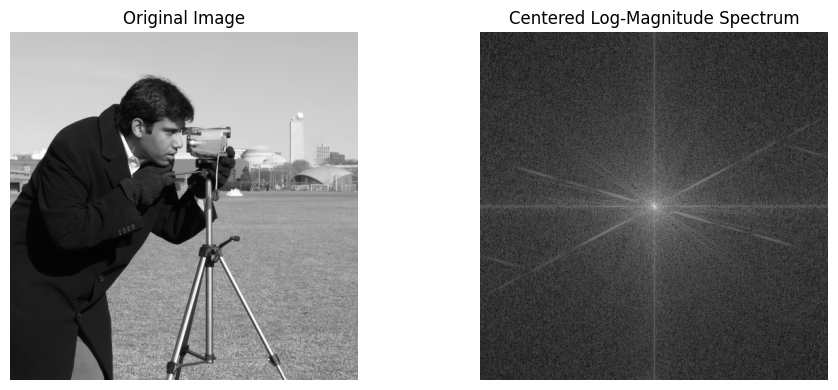

In [4]:
F_shift, log_mag = compute_fft(image)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(log_mag, cmap='gray')
axes[1].set_title('Centered Log-Magnitude Spectrum')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Main Function — Test Each Filter Separately

In [5]:
def main(image, filter_type='ideal_lowpass',
         cutoff=30, low_cut=20, high_cut=60, sigma=30,
         sigma_low=10, sigma_high=40):
    """
    Test a single filter on the input image.

    Parameters
    ----------
    filter_type : str
        One of: 'ideal_lowpass', 'ideal_highpass', 'ideal_bandpass',
                'gaussian_lowpass', 'gaussian_highpass', 'gaussian_bandpass'
    cutoff      : radius (pixels) for ideal LP/HP
    low_cut     : inner radius for ideal BP
    high_cut    : outer radius for ideal BP
    sigma       : std-dev for Gaussian LP/HP
    sigma_low   : inner sigma for Gaussian BP
    sigma_high  : outer sigma for Gaussian BP
    """
    shape = image.shape
    F_shift, orig_log = compute_fft(image)

    # Build filter mask
    if   filter_type == 'ideal_lowpass':      H = ideal_lowpass(shape, cutoff)
    elif filter_type == 'ideal_highpass':     H = ideal_highpass(shape, cutoff)
    elif filter_type == 'ideal_bandpass':     H = ideal_bandpass(shape, low_cut, high_cut)
    elif filter_type == 'gaussian_lowpass':   H = gaussian_lowpass(shape, sigma)
    elif filter_type == 'gaussian_highpass':  H = gaussian_highpass(shape, sigma)
    elif filter_type == 'gaussian_bandpass':  H = gaussian_bandpass(shape, sigma_low, sigma_high)
    else:
        raise ValueError(f'Unknown filter_type: {filter_type}')

    result, filtered_log = apply_filter(F_shift, H)
    show_result(image, orig_log, filtered_log, result, filter_type.replace('_', ' ').title())
    return result

print('main() defined.')

main() defined.


### 5.1 Ideal Low-Pass Filter (cutoff = 30)

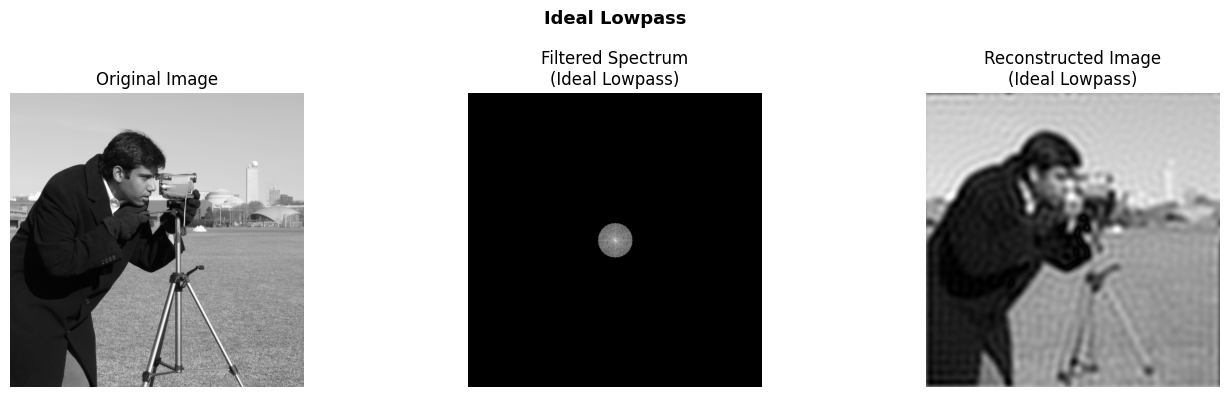

In [6]:
_ = main(image, filter_type='ideal_lowpass', cutoff=30)

### 5.2 Ideal High-Pass Filter (cutoff = 30)

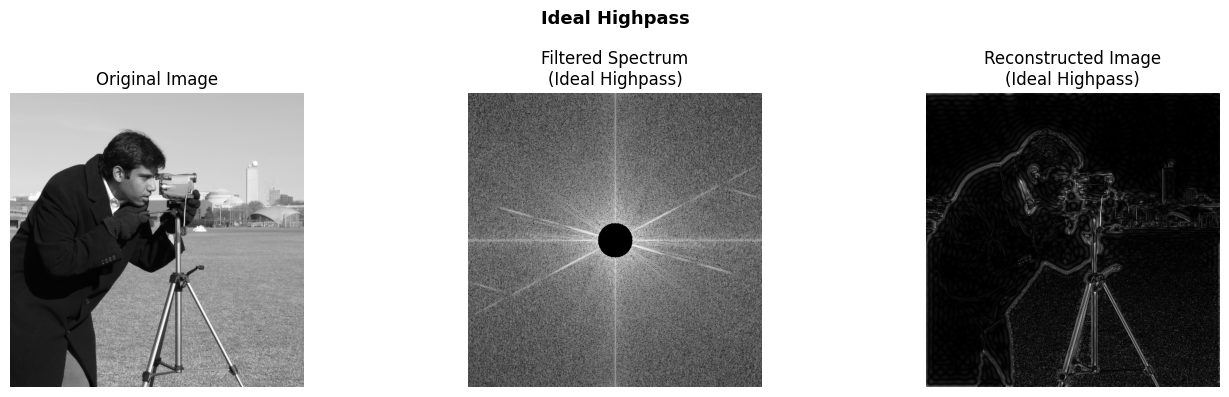

In [7]:
_ = main(image, filter_type='ideal_highpass', cutoff=30)

### 5.3 Ideal Band-Pass Filter (20 ≤ D ≤ 60)

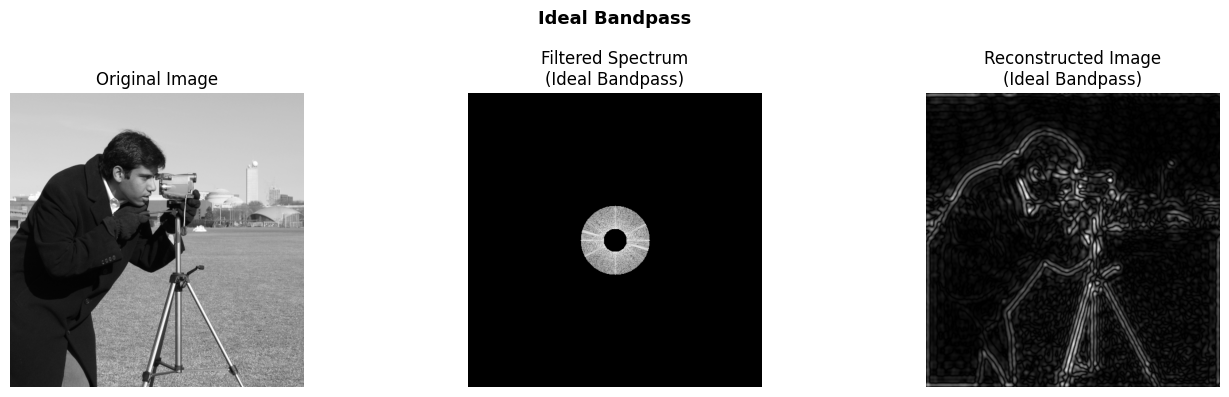

In [8]:
_ = main(image, filter_type='ideal_bandpass', low_cut=20, high_cut=60)

### 5.4 Gaussian Low-Pass Filter (σ = 30)

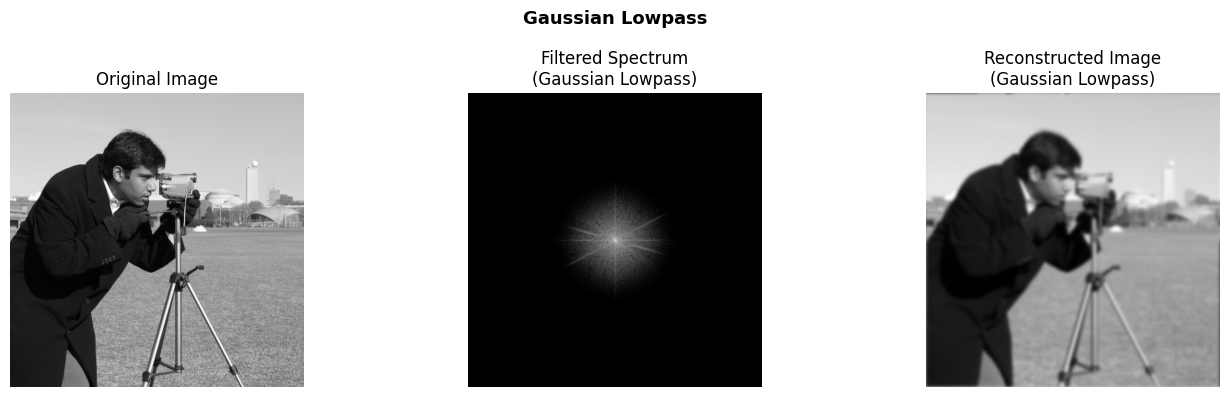

In [9]:
_ = main(image, filter_type='gaussian_lowpass', sigma=30)

### 5.5 Gaussian High-Pass Filter (σ = 30)

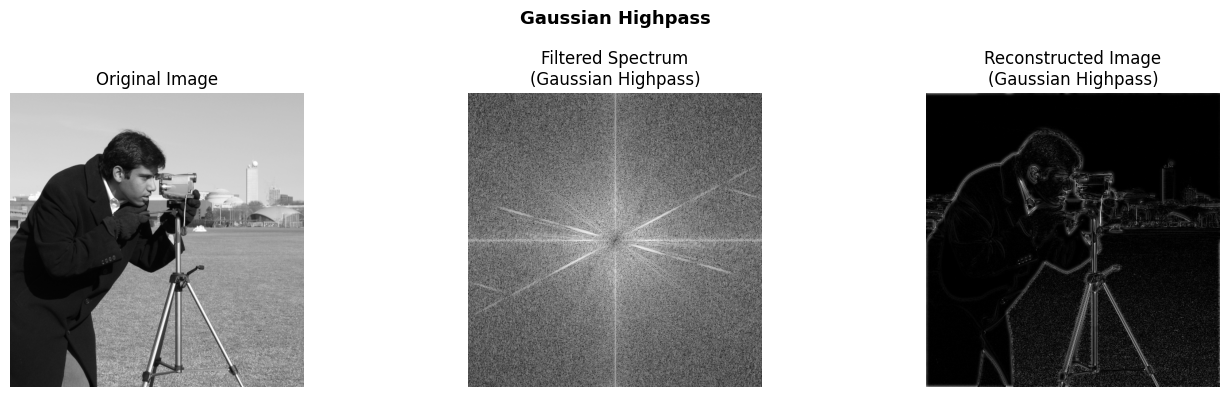

In [10]:
_ = main(image, filter_type='gaussian_highpass', sigma=30)

### 5.6 Gaussian Band-Pass Filter (σ_low = 10, σ_high = 40)

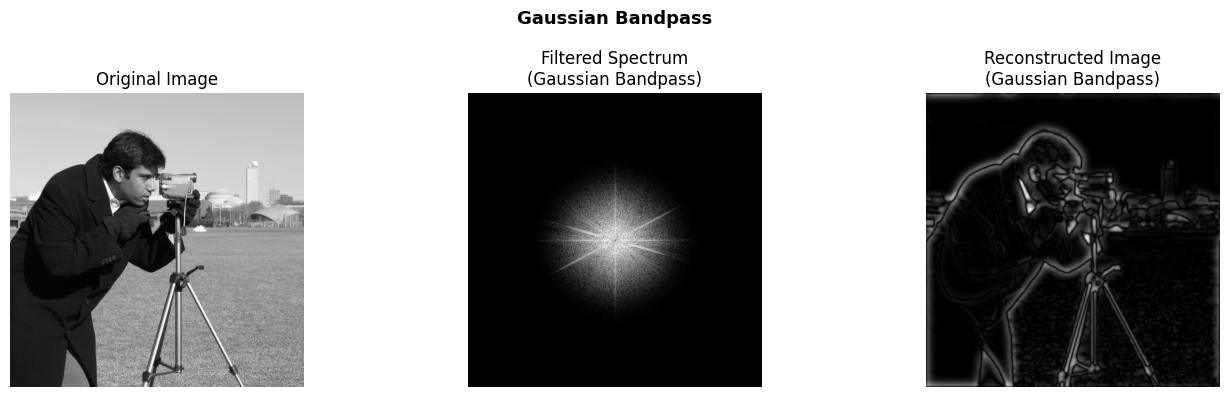

In [11]:
_ = main(image, filter_type='gaussian_bandpass', sigma_low=10, sigma_high=40)

## 6. Downsampling & Aliasing in the Frequency Domain
Downsampling an image (reducing spatial resolution without prior anti-aliasing) causes **aliasing** — visible as ripple/ring artefacts in the frequency spectrum. We demonstrate this below.

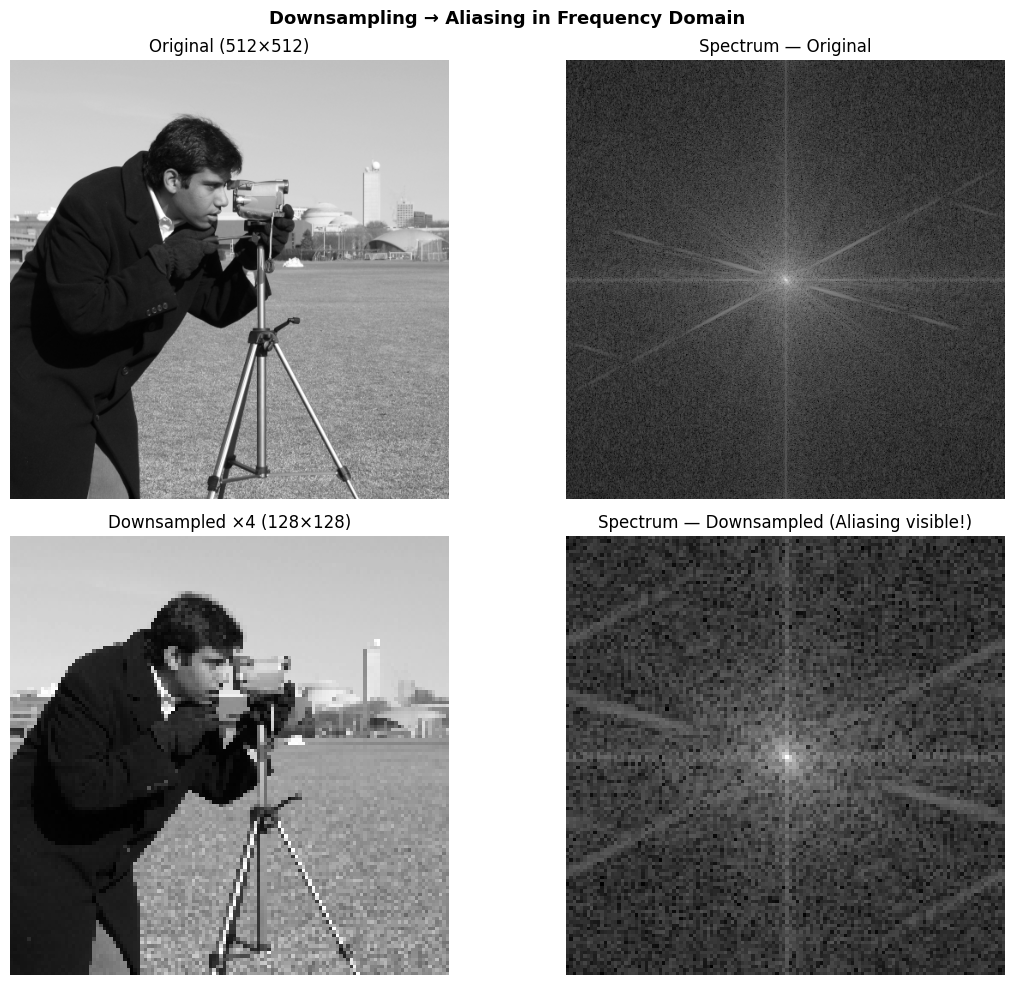

In [12]:
def demonstrate_downsampling(image, factor=4):
    """
    Downsample `image` by `factor` in the spatial domain (no pre-filtering),
    then compare the frequency spectra of the original and downsampled images.
    """
    # ── Naive downsampling (slice every `factor` pixels → aliasing)
    downsampled = image[::factor, ::factor]

    # ── FFT of both
    _, log_orig  = compute_fft(image)
    _, log_down  = compute_fft(downsampled)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].imshow(image,       cmap='gray')
    axes[0, 0].set_title(f'Original ({image.shape[0]}×{image.shape[1]})')

    axes[0, 1].imshow(log_orig,    cmap='gray')
    axes[0, 1].set_title('Spectrum — Original')

    axes[1, 0].imshow(downsampled, cmap='gray')
    axes[1, 0].set_title(f'Downsampled ×{factor} ({downsampled.shape[0]}×{downsampled.shape[1]})')

    axes[1, 1].imshow(log_down,    cmap='gray')
    axes[1, 1].set_title(f'Spectrum — Downsampled (Aliasing visible!)')

    for ax in axes.flat:
        ax.axis('off')

    plt.suptitle('Downsampling → Aliasing in Frequency Domain', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return downsampled


downsampled = demonstrate_downsampling(image, factor=4)

### Observation
- The **original** spectrum shows a smooth energy distribution centred at DC.
- After naive downsampling (factor = 4), the spectrum shows **replicated/overlapping copies** of the original spectrum — the characteristic signature of **aliasing** (ripple artefacts).
- Applying a **Gaussian low-pass filter before downsampling** (anti-aliasing) removes these artefacts.

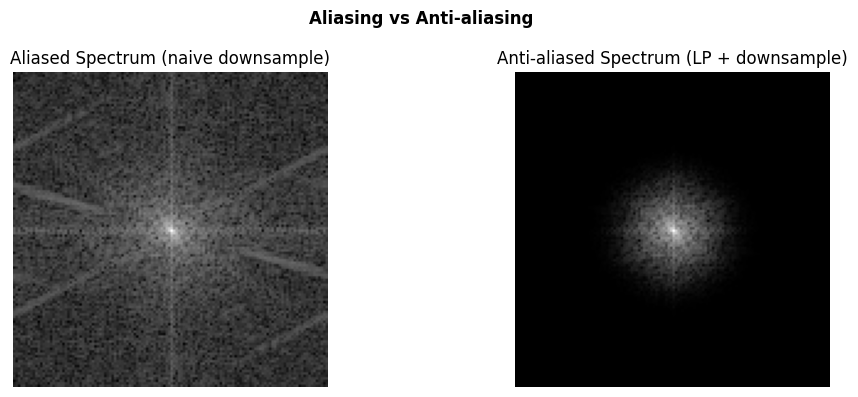

In [13]:
# ── Anti-aliased downsampling for comparison
def antialias_downsample(image, factor=4, sigma=10):
    """Apply Gaussian LP filter first, then downsample."""
    F_shift, _ = compute_fft(image)
    H = gaussian_lowpass(image.shape, sigma)
    smooth, _ = apply_filter(F_shift, H)
    ds_smooth = smooth[::factor, ::factor]
    _, log_ds_smooth = compute_fft(ds_smooth)
    return ds_smooth, log_ds_smooth

ds_smooth, log_ds = antialias_downsample(image, factor=4, sigma=10)
_, log_naive       = compute_fft(downsampled)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(log_naive, cmap='gray'); axes[0].set_title('Aliased Spectrum (naive downsample)')
axes[1].imshow(log_ds,    cmap='gray'); axes[1].set_title('Anti-aliased Spectrum (LP + downsample)')
for ax in axes: ax.axis('off')
plt.suptitle('Aliasing vs Anti-aliasing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Summary

| Filter | Effect on Image | Effect on Spectrum |
|---|---|---|
| Ideal Low-Pass | Blurs / smooths | Keeps low-freq disk, zeros high-freq |
| Ideal High-Pass | Sharpens / edges | Removes center, keeps outer ring |
| Ideal Band-Pass | Mid-frequency detail | Annular region in spectrum |
| Gaussian LP | Smooth blur (no ringing) | Soft Gaussian envelope |
| Gaussian HP | Soft edge detection | Complement of Gaussian envelope |
| Gaussian BP | Band of detail | Difference of two Gaussian LP masks |
| Naive Downsample | Spatial resolution ↓ | Aliasing ripples in spectrum |